<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day08_practice1_%EC%A6%9D%EA%B0%95_%ED%95%B4%EB%B6%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# 데이터 증강 (Data Augmentation) - 공짜로 데이터 늘리기
# 증강은 '학습'에만, 평가에는 절대 안 한다

import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

torch.manual_seed(42)

In [14]:
# [셀 1] 재료 - 옷 사진 한 장 준비
def load_fmnist(root="./data", train=True, transform=None):
  return datasets.FashionMNIST(root=root, train=train, download=True, transform=transform) # 데이터셋에서 이미지를 꺼낼 때 자동으로 적용할 전처리 함수를 지

data = load_fmnist()   # 데이터셋 로드 (transform 없음)
# 데이터 형식 : IDX 바이너리 4파일(이미지 28x28 unit + 라벨)

In [16]:
img_pil, label = data.data[0], data.targets[0] # 1번째 원본
img = img_pil.unsqueeze(0).float() / 255.0 # (28, 28) -> (1,28,28) 채널축 추가, 0-255->0-1 정규화
print("재료:", data.classes[label])

재료: Ankle boot


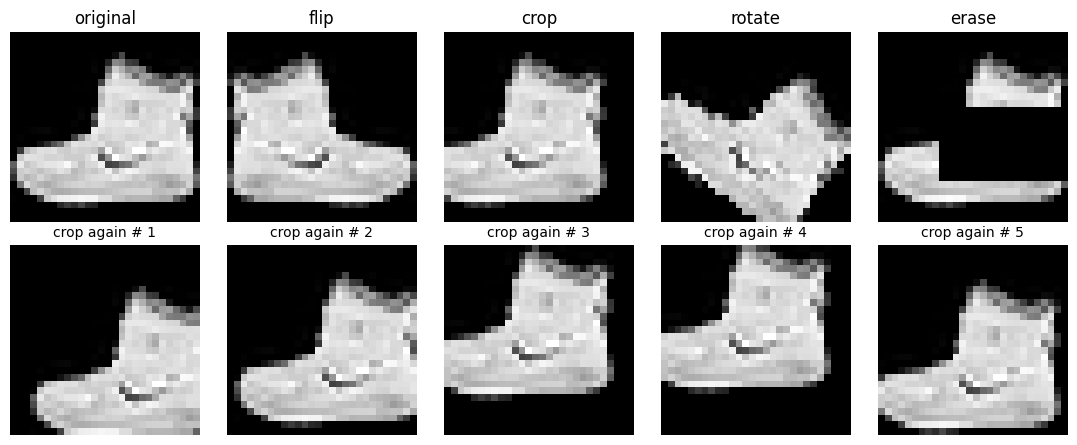

In [15]:
# [셀 2] 증강
# 각 반환은 '확률적' - 부를 때마다 조금씩 다른 결과가 나온다
augs = {
    "flip":     transforms.RandomHorizontalFlip(p=1.0), # 좌우 뒤집기 (p=1.0: 항상 뒤집음)
    "crop":     transforms.RandomCrop(28, padding=4), # 랜덤 자르기 (=살짝 이동)
    "rotate":   transforms.RandomRotation(90),        # ±90도 사이 무작위 회전
    "erase":    transforms.RandomErasing(p=1.0, scale=(0.25, 0.25)), # 일부 영역을 무작위로 가림

}

fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))
axes[0][0].imshow(img[0], cmap="gray")
axes[0][0].set_title("original")
axes[0][0].axis("off") # 첫칸=원본, .axis("off") 눈금 숨기기

for ax, (name, aug) in zip(axes.flat[1:5], augs.items()):  # 윗줄 나머지 4칸 - 증강 4종
    ax.imshow(aug(img)[0], cmap="gray")
    ax.set_title(name)
    ax.axis("off")

for i, ax in enumerate(axes.flat[5:]):  # 아랫줄 5칸 = 같은 crop을 5번 반복
    ax.imshow(augs["crop"](img)[0], cmap="gray")
    ax.set_title(f"crop again # {i+1}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("plot_augs.png")
plt.show()

# 과적합 - 문제집 암기
# 과적합을 줄이는 이유 : 매 에폭 사진이 조금씩 달라지면 특정 픽셀 배치를 암기할 수 없고, "어떤 각도 · 위치든 신발은 신발" 이라는 본질만 남는다.

In [17]:
# [셀 3] Compose - 변환을 파이프라인으로 묶기 (학습용 vs 평가용)
train_tf = transforms.Compose([ # 학습용: 증강 포함, transforms.Compose() 여러 전처리 변환을 순서대로 묶어 하나로 만드는 도구
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
])

test_tf = transforms.Compose([ # 평가용: 증강 없음
    transforms.ToTensor(),
])

train_aug = load_fmnist(train=True, transform=train_tf) # 증강 있는 학습셋
test_set = load_fmnist(train=False, transform=test_tf)   # 증강 없는 테스트셋

x1, _ = train_aug[7]
x2, _ = train_aug[7]
print("\n같은 인덱스 [7]를 두 번 꺼내면:", "다르다" if not torch.equal(x1, x2) else "같다")


같은 인덱스 [7]를 두 번 꺼내면: 다르다
